# Анализ лояльности пользователей Яндекс Афиши

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `A`
- **База данных** — `B`
- **Порт** — `C`
- **Аутентификация** — `D`
- **Пользователь** — `E`
- **Пароль** — `F`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [ ]:
%pip install pandas numpy matplotlib sqlalchemy psycopg2 phik seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [2]:
db_config = {'user': 'A', # имя пользователя
             'pwd': 'B', # пароль
             'host': 'C',
             'port': D, # порт подключения
             'db': 'E' # название базы данных
             }

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
select
  p.user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk order_dt,
  p.created_ts_msk order_ts,
  p.currency_code,
  round(p.revenue::numeric, 2) revenue,
  p.tickets_count,
  extract(days from p.created_dt_msk - lag(p.created_dt_msk) over (partition by p.user_id order by p.created_dt_msk)) days_since_prev,
  p.event_id,
  e.event_name_code event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
from afisha.purchases p
join afisha.events e on p.event_id = e.event_id
join afisha.city c on e.city_id = c.city_id
join afisha.regions r on c.region_id = r.region_id
where p.device_type_canonical in ('mobile', 'desktop') and e.event_type_main != 'фильм'
order by user_id
'''

In [6]:
df = pd.read_sql_query(query, con=engine)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


---

### 2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


In [9]:
try:
    df_kzt_rub = pd.read_csv('/datasets/final_tickets_tenge_df.csv')
except FileNotFoundError:
    try:
        df_kzt_rub = pd.read_csv('datasets/final_tickets_tenge_df.csv')
    except FileNotFoundError:
        try:
            df_kzt_rub = pd.read_csv('final_tickets_tenge_df.csv')
        except FileNotFoundError:
            raise FileNotFoundError('Файл не найден.')

In [10]:
df_kzt_rub['data'] = pd.to_datetime(df_kzt_rub['data'])
df_kzt_rub.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   data     357 non-null    datetime64[us]
 1   nominal  357 non-null    int64         
 2   curs     357 non-null    float64       
 3   cdx      357 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 11.3 KB


In [11]:
df_kzt_rub['kzt_to_rub'] = (df_kzt_rub[(df_kzt_rub['data'] > '2024-05-31') & (df_kzt_rub['data'] < '2024-11-01')]['nominal'] / df_kzt_rub['curs'])

In [12]:
df_kzt_rub = df_kzt_rub.dropna().reset_index(drop=True)
df_kzt_rub = df_kzt_rub[['data', 'kzt_to_rub']]
df_kzt_rub['kzt_to_rub'] = df_kzt_rub['kzt_to_rub'].astype('float32')
df_kzt_rub.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   data        153 non-null    datetime64[us]
 1   kzt_to_rub  153 non-null    float32       
dtypes: datetime64[us](1), float32(1)
memory usage: 1.9 KB


In [13]:
df = df.merge(df_kzt_rub, left_on='order_dt', right_on='data', how='left')
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,kzt_to_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,2024-08-20,5.348394
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,2024-07-23,5.451998
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,2024-10-06,5.089706
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,2024-07-13,5.405113
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,2024-10-04,5.085228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,2024-10-27,5.018417
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,2024-10-27,5.018417
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,2024-10-30,5.012129
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,2024-09-24,5.155516


In [14]:
df['revenue_rub'] = np.where(
    df['currency_code'] == 'kzt',
    df['revenue'] / df['kzt_to_rub'],
    df['revenue']
)

In [15]:
df[df['currency_code'] == 'kzt']

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,data,kzt_to_rub,revenue_rub
70,0033403583a55ed,mobile,7850214,2024-09-17,2024-09-17 16:52:06,kzt,518.10,4,20.0,559919,f5ec2467-ee48-42f3-89a0-a2d90d1d6fce,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-17,5.259697,98.503765
89,0040e12d70fae81,desktop,8634925,2024-09-02,2024-09-02 19:49:14,kzt,347.18,3,39.0,559476,61ec7c0e-ea0c-4a3e-a63a-09cbe1bc6177,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-02,5.281783,65.731590
96,0054b38b2653e6e,mobile,7625522,2024-09-09,2024-09-09 18:06:04,kzt,328.77,4,NaN,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-09,5.376604,61.148263
277,00f4f5244501ce6,mobile,720419,2024-06-11,2024-06-11 20:15:57,kzt,22021.60,5,NaN,536826,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Верхоречная область,Серебрянка,2024-06-11,5.026945,4380.712657
460,01370a0e9c1a7d5,desktop,5227657,2024-06-04,2024-06-04 13:28:17,kzt,7397.66,4,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,2024-06-04,5.004179,1478.296580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290484,ffc24188a1d58f2,mobile,6862648,2024-07-11,2024-07-11 12:39:48,kzt,4735.52,2,20.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,2024-07-11,5.472316,865.359417
290485,ffc24188a1d58f2,mobile,6763294,2024-09-05,2024-09-05 12:07:00,kzt,4735.52,2,56.0,538828,603c97c6-b64f-4ec6-8de9-20b95c20b2b5,концерты,Билеты без проблем,Верхоречная область,Серебрянка,2024-09-05,5.428380,872.363315
290486,ffc24188a1d58f2,mobile,3984021,2024-09-06,2024-09-06 19:20:03,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,2024-09-06,5.390719,343.072948
290488,ffc4133fbba20f4,mobile,8493898,2024-06-21,2024-06-21 13:41:39,kzt,3698.83,2,NaN,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,2024-06-21,5.382392,687.209339


In [16]:
df = df.drop(columns=['data', 'kzt_to_rub'])
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.57,4,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,965.57
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.36,6,0.0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,1448.36
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.95,2,3.0,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,178.95
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.53,2,NaN,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,661.53


---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [18]:
df['device_type_canonical'].unique()

<StringArray>
['mobile', 'desktop']
Length: 2, dtype: str

In [19]:
df['currency_code'].unique()

<StringArray>
['rub', 'kzt']
Length: 2, dtype: str

In [20]:
df['event_name'].unique()

<StringArray>
['f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad',
 '40efeb04-81b7-4135-b41f-708ff00cc64c',
 '01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca',
 '2f638715-8844-466c-b43f-378a627c419f',
 '10d805d3-9809-4d8a-834e-225b7d03f95d',
 '9cc55c15-4375-4129-9979-3129688ba1b4',
 '2f98d69f-4e60-4ffc-8f16-e539383526b1',
 '0d876e01-851e-458b-ba61-753e0e0c4063',
 'ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1',
 '11be386f-7cb7-4aa1-a8e4-ba73a29c1af2',
 ...
 'b508ef8b-526b-4f1c-9f57-96deba1d773f',
 '8d392c51-baeb-48af-8d77-bec526ece12d',
 '0a2862c9-2d23-4bd7-bf18-9d82f39a2020',
 'c56473e5-bc60-43fa-842c-89383777739a',
 'f5ed29fa-f5e5-4c8b-96ad-2e35c7e8342c',
 'aec82c6e-1155-4dd2-801a-e4b2ac9824a6',
 'f56f3d67-4673-4fb3-b202-3f2bfd39fcf6',
 'cf71bf2b-8e5c-47e0-a0f3-c2d4910c4677',
 'f17a01b7-3cd3-4cd1-919c-3459bd074886',
 '0fd6df8e-49e5-4337-954d-5a4606b1b899']
Length: 15248, dtype: str

In [21]:
df['event_type_main'].unique()

<StringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str

In [22]:
df['service_name'].unique()

<StringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',           'Цвет и билет',               'Зе Бест!',
              'Тех билет',                 'Лимоны',     'Билеты в интернете']
Length: 36, dtype: str

In [23]:
df['region_name'].unique()

<StringArray>
[       'Каменевский регион',      'Североярская область',
          'Озернинский край',      'Лугоградская область',
          'Поленовский край',       'Широковская область',
         'Медовская область',       'Златопольский округ',
      'Малиновоярский округ',       'Яблоневская область',
         'Ветренский регион',         'Боровлянский край',
      'Крутоводская область',      'Ягодиновская область',
     'Серебряноярский округ',          'Лесодальний край',
       'Верхоречная область',      'Горицветская область',
       'Речиновская область',         'Травиницкий округ',
        'Сосновская область',      'Серебринская область',
          'Травяная область',        'Каменноярский край',
   'Солнечноземская область',      'Светополянский округ',
          'Заречная область',         'Ручейковский край',
      'Глиногорская область',      'Тепляковская область',
       'Каменноозёрный край', 'Солнечнореченская область',
          'Зоринский регион',       'Берёз

In [24]:
df['city_name'].unique()

<StringArray>
[   'Глиногорск',        'Озёрск',   'Родниковецк',   'Кристалевск',
 'Дальнозолотск',  'Радужнополье',     'Радужсвет',        'Кумсай',
     'Верховино',    'Светополье',
 ...
    'Дальнеград',     'Горноград',   'Березовцево',     'Берёзовка',
   'Дальнозелен',       'Травино',     'Карасуйск',      'Кызылжол',
     'Поляновск',     'Лесогорск']
Length: 352, dtype: str

In [25]:
df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['revenue'] = df['revenue'].astype('float32')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = df['days_since_prev'].astype('Int16').astype('Int8')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int8          
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [27]:
df

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.939941,4,<NA>,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.450012,2,<NA>,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.569946,4,75,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.490000,2,<NA>,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.410034,3,83,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290606,fffcd3dde79eb2c,mobile,368591,2024-10-27,2024-10-27 17:54:52,rub,965.570007,4,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,965.57
290607,fffcd3dde79eb2c,mobile,368562,2024-10-27,2024-10-27 17:53:53,rub,1448.359985,6,0,33189,e3dcdb45-9eaa-4ce4-9b85-1562e548172e,другое,Весь в билетах,Каменевский регион,Глиногорск,1448.36
290608,fffcd3dde79eb2c,desktop,8473772,2024-10-30,2024-10-30 13:37:43,rub,178.949997,2,3,205231,74883818-57a6-494a-b162-bb0260877cbf,театр,Прачечная,Каменевский регион,Глиногорск,178.95
290609,fffeeb3c120cf0b,desktop,5526067,2024-09-24,2024-09-24 10:07:42,rub,661.530029,2,<NA>,454526,6f4c6a50-0106-407b-8f54-332c740b01da,стендап,Билеты без проблем,Широковская область,Ягодиновка,661.53


In [28]:
df[['revenue_rub', 'tickets_count']].describe()

,revenue_rub,tickets_count
count,290611.000000,290611.000000
mean,555.571975,2.754311
std,875.497903,1.170620
min,-90.760000,1.000000
25%,113.970000,2.000000
50%,351.140000,3.000000
75%,802.050000,4.000000
max,81174.500000,57.000000


In [29]:
df[df['revenue_rub'] < 0].head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
252,00eb3dc9baa1543,mobile,1594653,2024-06-29,2024-06-29 15:01:43,rub,-2.37,3,<NA>,538650,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,другое,Билеты без проблем,Берёзовская область,Златопольск,-2.37
4539,02ea4583333f064,mobile,2360920,2024-09-03,2024-09-03 18:12:58,rub,-0.23,3,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,другое,Билеты без проблем,Широковская область,Лесореченск,-0.23
4544,02ea4583333f064,mobile,2361094,2024-09-04,2024-09-04 09:34:53,rub,-0.15,2,0,559772,592856bb-09a5-4d32-9534-0e02c6056e44,другое,Билеты без проблем,Широковская область,Лесореченск,-0.15
8135,043f669c9f734b1,mobile,166780,2024-09-27,2024-09-27 10:00:09,rub,-1.86,3,0,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,другое,Лучшие билеты,Золотоключевской край,Луговинец,-1.86
8136,043f669c9f734b1,mobile,166809,2024-09-27,2024-09-27 10:56:35,rub,-0.62,1,0,567183,9f571dad-b18a-4095-ac76-9db60d8dd97a,другое,Лучшие билеты,Золотоключевской край,Луговинец,-0.62
11342,06727636bf2f465,mobile,6620527,2024-06-30,2024-06-30 05:40:34,rub,-1.58,2,24,538650,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,другое,Билеты без проблем,Берёзовская область,Златопольск,-1.58
11343,06727636bf2f465,mobile,6620498,2024-07-01,2024-07-01 04:52:51,rub,-1.58,2,1,538648,ffe03bc6-0e0c-480d-b037-6a4b55540ab5,другое,Билеты без проблем,Берёзовская область,Златопольск,-1.58
11568,067494310c6617f,mobile,8333963,2024-10-07,2024-10-07 09:32:35,rub,-6.18,4,0,569499,b6975aa8-5c9e-408d-bfc8-74fd8189a04f,спорт,Билеты в руки,Дальнеземская область,Теплоозёрск,-6.18
11619,067494310c6617f,mobile,4930755,2024-10-24,2024-10-24 17:48:42,rub,-3.59,1,1,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,Билеты в руки,Малиновая область,Зеленополье,-3.59
11622,067494310c6617f,mobile,8350029,2024-10-24,2024-10-24 17:46:44,rub,-10.77,3,0,568916,b1a3919a-5d3e-4da2-b6f5-eccb480d810c,другое,Билеты в руки,Малиновая область,Зеленополье,-10.77


In [30]:
df.loc[df['revenue_rub'] < 0, 'revenue_rub'] = 0.0
df.loc[df['revenue'] < 0, 'revenue'] = 0.0

In [31]:
df[df['revenue_rub'] == 81174.5]

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
122336,5b5714894bd0517,mobile,4113535,2024-08-03,2024-08-03 22:36:13,rub,81174.5,5,3,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,81174.5
122337,5b5714894bd0517,mobile,4113477,2024-08-03,2024-08-03 22:37:17,rub,81174.5,5,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,81174.5
183754,96368e5714d1673,mobile,8067453,2024-08-24,2024-08-24 13:56:40,rub,81174.5,5,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,81174.5


In [32]:
df[df['event_id'] == 552398].head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
11121,061b378a1519041,mobile,3329694,2024-08-06,2024-08-06 12:55:50,rub,48704.699219,3,6,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,48704.7
28942,0ea528819041df1,mobile,4874988,2024-08-17,2024-08-17 20:07:57,rub,48704.699219,3,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,48704.7
30655,1021a86d7ee6fb8,mobile,4476035,2024-08-12,2024-08-12 12:06:51,rub,16234.900391,1,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,16234.9
37317,189a66f168cc825,mobile,5927920,2024-09-08,2024-09-08 10:37:46,rub,16234.900391,1,7,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,16234.9
42884,1a1514f0360ff18,mobile,3992344,2024-09-26,2024-09-26 16:26:47,rub,32469.800781,2,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,32469.8
42885,1a1514f0360ff18,mobile,3992286,2024-09-26,2024-09-26 16:26:15,rub,16234.900391,1,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,16234.9
42886,1a1514f0360ff18,mobile,3992373,2024-09-26,2024-09-26 16:30:48,rub,32469.800781,2,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,32469.8
50503,1e814c3bab7d73a,mobile,1495444,2024-10-04,2024-10-04 16:34:13,rub,48704.699219,3,15,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,48704.7
51361,1f49b8de206b285,mobile,3246754,2024-08-31,2024-08-31 22:05:17,rub,48704.699219,3,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,48704.7
68932,2fff690c8383fd9,mobile,7150937,2024-08-07,2024-08-07 16:36:32,rub,32469.800781,2,0,552398,b443dc5a-fff2-4b69-8684-0719fff49b59,концерты,Облачко,Североярская область,Озёрск,32469.8


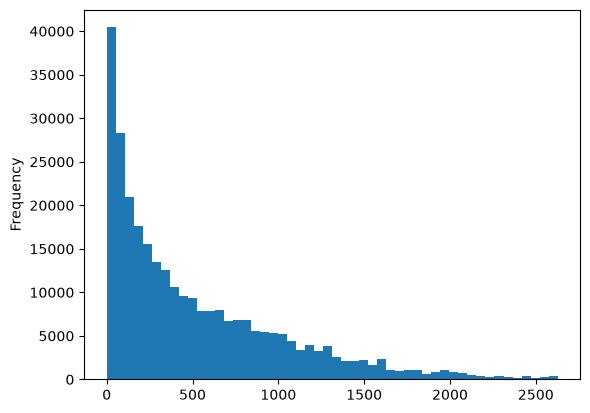

In [33]:
df[df['revenue_rub'] < df['revenue_rub'].quantile(0.99)]['revenue_rub'].plot(kind='hist', bins=50)
plt.show()

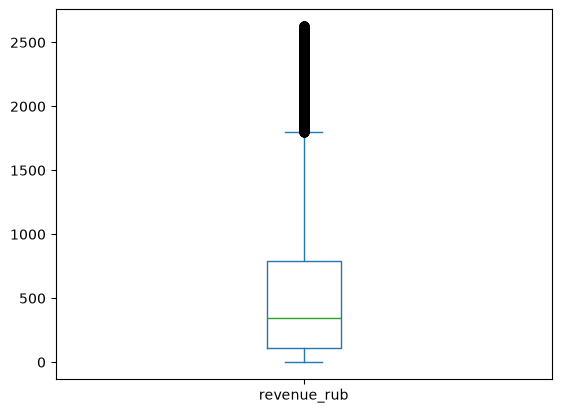

In [34]:
df[df['revenue_rub'] < df['revenue_rub'].quantile(0.99)]['revenue_rub'].plot(kind='box')
plt.show()

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int32         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float32       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int8          
 9   event_id               290611 non-null  int32         
 10  event_name             290611 non-null  str           
 11  event_type_main        290611 non-null  str           
 12  service_name           290611 non-null  str           


In [36]:
user_profile = df.sort_values(by='order_ts', ascending=True)

In [37]:
user_profile = user_profile.groupby('user_id').agg(
    first_order_date = ('order_dt', 'min'),
    last_order_date = ('order_dt', 'max'),
    first_order_device = ('device_type_canonical', 'first'),
    first_order_region = ('region_name', 'first'),
    first_service_name = ('service_name', 'first'),
    first_event_type = ('event_type_main', 'first'),
    orders_quantity = ('order_id', 'count'),
    avg_revenue_rub = ('revenue_rub', 'mean'),
    avg_tickets_quantity = ('tickets_count', 'mean'),
    avg_days_since_prev = ('days_since_prev', 'mean')
).reset_index()

In [38]:
user_profile['orders_quantity'] = pd.to_numeric(user_profile['orders_quantity'], downcast='integer')
user_profile['avg_revenue_rub'] = pd.to_numeric(user_profile['avg_revenue_rub'], downcast='float')
user_profile['avg_tickets_quantity'] = pd.to_numeric(user_profile['avg_tickets_quantity'], downcast='float')
user_profile['avg_days_since_prev'] = user_profile['avg_days_since_prev'].astype('float32')

In [39]:
user_profile.info()

<class 'pandas.DataFrame'>
RangeIndex: 21933 entries, 0 to 21932
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               21933 non-null  str           
 1   first_order_date      21933 non-null  datetime64[us]
 2   last_order_date       21933 non-null  datetime64[us]
 3   first_order_device    21933 non-null  str           
 4   first_order_region    21933 non-null  str           
 5   first_service_name    21933 non-null  str           
 6   first_event_type      21933 non-null  str           
 7   orders_quantity       21933 non-null  int16         
 8   avg_revenue_rub       21933 non-null  float64       
 9   avg_tickets_quantity  21933 non-null  float32       
 10  avg_days_since_prev   13559 non-null  float32       
dtypes: datetime64[us](2), float32(2), float64(1), int16(1), str(5)
memory usage: 1.5 MB


In [40]:
user_profile['is_two'] = (user_profile['orders_quantity'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['orders_quantity'] >= 5).astype(int)
user_profile['is_two'] = pd.to_numeric(user_profile['is_two'], downcast='integer')
user_profile['is_five'] = pd.to_numeric(user_profile['is_five'], downcast='integer')
user_profile

,user_id,first_order_date,last_order_date,first_order_device,first_order_region,first_service_name,first_event_type,orders_quantity,avg_revenue_rub,avg_tickets_quantity,avg_days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.000,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.000,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.000,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21928,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,Каменевский регион,Мой билет,другое,9,688.043333,2.555556,13.375,1,1
21929,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.995000,2.500000,74.000,1,0
21930,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.908485,2.787879,4.125,1,1
21931,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,Широковская область,Билеты без проблем,стендап,1,661.530000,2.000000,NaN,0,0


---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

In [41]:
user_profile['user_id'].count()

np.int64(21933)

In [42]:
user_profile['avg_revenue_rub'].mean().round(2)

np.float64(574.02)

In [43]:
user_profile['is_two'].mean().round(2)

np.float64(0.62)

In [44]:
user_profile['is_five'].mean().round(2)

np.float64(0.29)

In [45]:
user_profile[['orders_quantity', 'avg_tickets_quantity', 'avg_days_since_prev']].describe()

,orders_quantity,avg_tickets_quantity,avg_days_since_prev
count,21933.000000,21933.000000,13559.000000
mean,13.249943,2.755987,14.265870
std,122.470535,0.920739,22.834787
min,1.000000,1.000000,-128.000000
25%,1.000000,2.000000,0.961782
50%,2.000000,2.764151,7.800000
75%,5.000000,3.125000,19.666666
max,10251.000000,12.000000,127.000000


In [46]:
user_profile[user_profile['orders_quantity'] == 10251]

,user_id,first_order_date,last_order_date,first_order_device,first_order_region,first_service_name,first_event_type,orders_quantity,avg_revenue_rub,avg_tickets_quantity,avg_days_since_prev,is_two,is_five
985,0beb8fc0c0a9ce1,2024-06-01,2024-10-31,mobile,Североярская область,Билеты в руки,концерты,10251,523.380671,2.873964,0.014829,1,1


In [47]:
df[df['user_id'] == '0beb8fc0c0a9ce1']

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
14637,0beb8fc0c0a9ce1,mobile,8468900,2024-06-01,2024-06-01 16:09:41,rub,149.449997,3,<NA>,414214,42b6155e-2868-4bf2-8e85-39461a656929,выставки,Лови билет!,Североярская область,Озёрск,149.45
14638,0beb8fc0c0a9ce1,mobile,8236900,2024-06-01,2024-06-01 12:06:03,rub,96.529999,1,0,496288,68b8af84-3ad2-429a-9ba5-32dd25e35f6b,концерты,Билеты в руки,Североярская область,Озёрск,96.53
14639,0beb8fc0c0a9ce1,desktop,8634258,2024-06-01,2024-06-01 10:38:11,rub,1297.219971,2,0,314894,31502b0e-f241-48ed-8aef-4b5201eb0fd7,концерты,Билеты без проблем,Малиновоярский округ,Верховино,1297.22
14640,0beb8fc0c0a9ce1,desktop,8634287,2024-06-01,2024-06-01 10:22:22,rub,1636.439941,3,0,509551,e1e937b0-a229-490b-b57f-4ef9630d5288,концерты,Билеты в руки,Североярская область,Озёрск,1636.44
14641,0beb8fc0c0a9ce1,mobile,5394407,2024-06-01,2024-06-01 22:54:26,rub,1477.729980,3,0,459673,e1a58a1f-b479-4b93-8636-82f5d7e7cd83,концерты,Весь в билетах,Яблоневская область,Светополье,1477.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24883,0beb8fc0c0a9ce1,mobile,8341532,2024-10-31,2024-10-31 23:25:38,rub,686.659973,4,0,328110,b37e6355-4980-4477-ac09-38ba99fea4d1,концерты,Лови билет!,Яблоневская область,Светополье,686.66
24884,0beb8fc0c0a9ce1,mobile,8361658,2024-10-31,2024-10-31 10:45:35,rub,655.450012,3,0,455467,a221b526-99e9-4a83-8f20-3dbfc32c49c5,концерты,Облачко,Озернинский край,Лесоярич,655.45
24885,0beb8fc0c0a9ce1,mobile,8470611,2024-10-31,2024-10-31 23:28:28,rub,161.240005,2,0,589623,93adfe2e-08bb-44bb-8679-0c500c5340e5,концерты,Мой билет,Каменевский регион,Глиногорск,161.24
24886,0beb8fc0c0a9ce1,mobile,8234174,2024-10-31,2024-10-31 04:56:36,rub,258.570007,2,0,445016,ff5d26f3-14b6-414d-b4af-c977ecbcc32a,театр,Тебе билет!,Речиновская область,Дальнесветск,258.57


In [48]:
user_profile.loc[user_profile['orders_quantity'] < user_profile['orders_quantity'].quantile(0.95), 'orders_quantity'].describe()

count    20834.000000
mean         4.067918
std          5.135055
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max         31.000000
Name: orders_quantity, dtype: float64

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


In [49]:
seg_first_event = pd.DataFrame({
    'users_count': user_profile['first_event_type'].value_counts(),
    'share': user_profile['first_event_type'].value_counts(normalize=True).round(3)
})
seg_first_device = pd.DataFrame({
    'users_count': user_profile['first_order_device'].value_counts(),
    'share': user_profile['first_order_device'].value_counts(normalize=True).round(3)
})
seg_first_region = pd.DataFrame({
    'users_count': user_profile['first_order_region'].value_counts(),
    'share': user_profile['first_order_region'].value_counts(normalize=True).round(3)
})
seg_first_service = pd.DataFrame({
    'users_count': user_profile['first_service_name'].value_counts(),
    'share': user_profile['first_service_name'].value_counts(normalize=True).round(3)
})

In [50]:
for seg in [seg_first_event, seg_first_device, seg_first_region, seg_first_service]:
    print(seg.head(10), '\n')

                  users_count  share
first_event_type                    
концерты                 9701  0.442
другое                   5489  0.250
театр                    4312  0.197
стендап                  1118  0.051
спорт                     804  0.037
выставки                  414  0.019
ёлки                       95  0.004 

                    users_count  share
first_order_device                    
mobile                    18161  0.828
desktop                    3772  0.172 

                      users_count  share
first_order_region                      
Каменевский регион           7209  0.329
Североярская область         3795  0.173
Широковская область          1244  0.057
Озернинский край              679  0.031
Малиновоярский округ          536  0.024
Шанырский регион              509  0.023
Травяная область              494  0.023
Светополянский округ          469  0.021
Речиновская область           442  0.020
Яблоневская область           419  0.019 

             

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


In [51]:
seg_first_event['repeat_share'] = (
    user_profile.groupby('first_event_type')['is_two'].mean().round(3)
)
seg_first_device['repeat_share'] = (
    user_profile.groupby('first_order_device')['is_two'].mean().round(3)
)
seg_first_region['repeat_share'] = (
    user_profile.groupby('first_order_region')['is_two'].mean().round(3)
)
seg_first_service['repeat_share'] = (
    user_profile.groupby('first_service_name')['is_two'].mean().round(3)
)

In [52]:
for seg in [seg_first_event, seg_first_device, seg_first_region, seg_first_service]:
    print(seg.head(10), '\n')

                  users_count  share  repeat_share
first_event_type                                  
концерты                 9701  0.442         0.624
другое                   5489  0.250         0.601
театр                    4312  0.197         0.639
стендап                  1118  0.051         0.610
спорт                     804  0.037         0.562
выставки                  414  0.019         0.640
ёлки                       95  0.004         0.547 

                    users_count  share  repeat_share
first_order_device                                  
mobile                    18161  0.828         0.613
desktop                    3772  0.172         0.642 

                      users_count  share  repeat_share
first_order_region                                    
Каменевский регион           7209  0.329         0.629
Североярская область         3795  0.173         0.642
Широковская область          1244  0.057         0.651
Озернинский край              679  0.031         0

In [53]:
overall_repeat = user_profile['is_two'].mean() * 100
f'Средняя доля 2+ заказов (повторных) по выборке: {overall_repeat:.2f}%'

'Средняя доля 2+ заказов (повторных) по выборке: 61.82%'

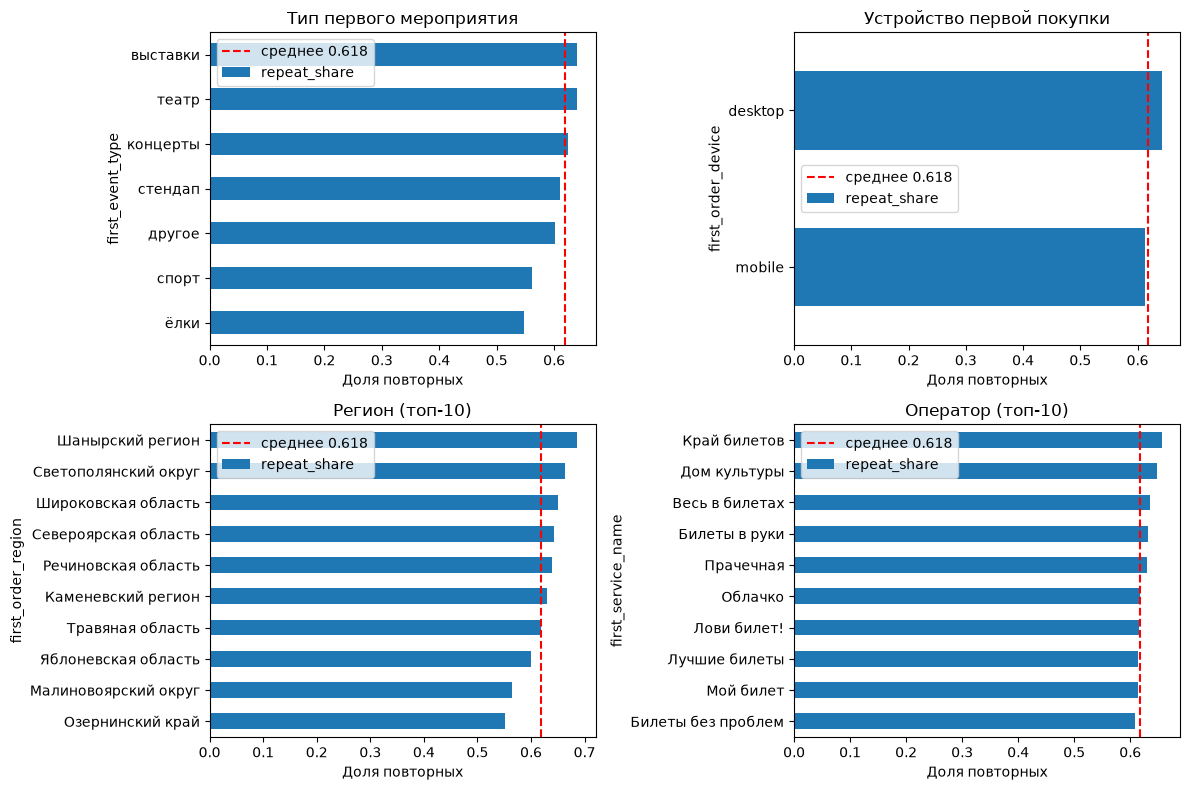

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (seg_first_event,   'Тип первого мероприятия', axes[0][0], False),
    (seg_first_device,  'Устройство первой покупки', axes[0][1], False),
    (seg_first_region,  'Регион (топ-10)',          axes[1][0], True),
    (seg_first_service, 'Оператор (топ-10)',        axes[1][1], True),
]

for seg, title, ax, top10 in plots:
    data = seg.nlargest(10, 'users_count') if top10 else seg
    data = data.sort_values('repeat_share')
    data['repeat_share'].plot(kind='barh', ax=ax, title=title)
    ax.axvline(overall_repeat/100, color='red', linestyle='--', label=f'среднее {overall_repeat/100:.3f}')
    ax.set_xlabel('Доля повторных')
    ax.legend()

plt.tight_layout()
plt.show()

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


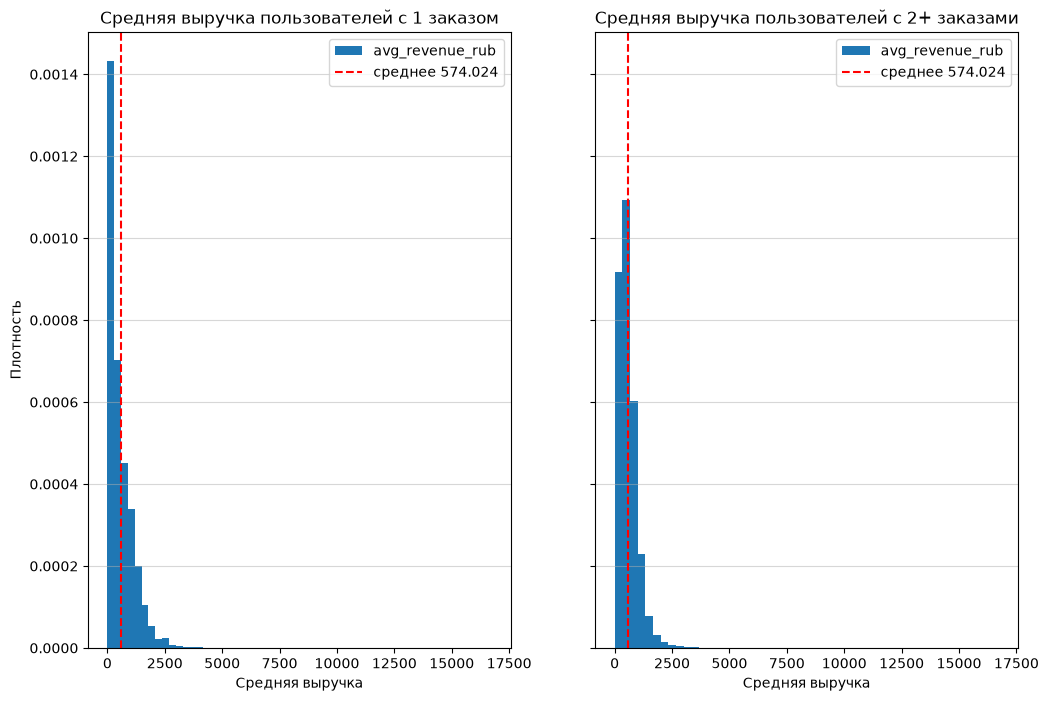

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

plots = [
    (user_profile[user_profile['orders_quantity'] == 1]['avg_revenue_rub'], 'Средняя выручка пользователей с 1 заказом', axes[0]),
    (user_profile[user_profile['orders_quantity'] >= 2]['avg_revenue_rub'], 'Средняя выручка пользователей с 2+ заказами', axes[1])
]

avg_revenue = user_profile['avg_revenue_rub'].mean().round(3)

for series, title, ax in plots:
    series.plot(kind='hist', ax=ax, title=title, bins=50, density=True)
    ax.set_xlabel('Средняя выручка')
    ax.axvline(avg_revenue, color='red', linestyle='--', label=f'среднее {avg_revenue}')
    ax.set_ylabel('Плотность')
    ax.legend()
    ax.grid(axis='y', alpha=0.5)
plt.show()

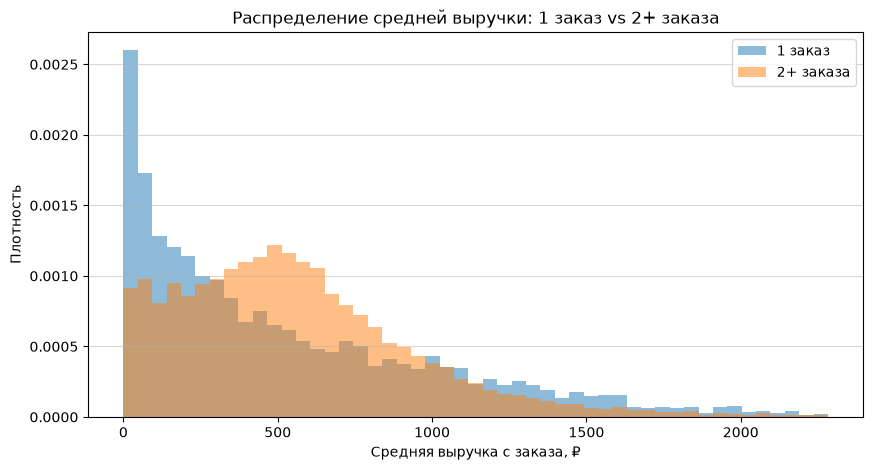

In [56]:
rev_1 = user_profile.loc[user_profile['orders_quantity'] == 1, 'avg_revenue_rub']
rev_2plus = user_profile.loc[user_profile['orders_quantity'] >= 2, 'avg_revenue_rub']

upper = user_profile['avg_revenue_rub'].quantile(0.99)
bins = np.linspace(0, upper, 50)

plt.figure(figsize=(10, 5))
plt.hist(rev_1[rev_1 < upper], bins=bins, density=True, alpha=0.5, label='1 заказ')
plt.hist(rev_2plus[rev_2plus < upper], bins=bins, density=True, alpha=0.5, label='2+ заказа')
plt.xlabel('Средняя выручка с заказа, ₽')
plt.ylabel('Плотность')
plt.title('Распределение средней выручки: 1 заказ vs 2+ заказа')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

In [57]:
pd.DataFrame({
    '1 заказ': rev_1.describe(),
    '2+ заказа': rev_2plus.describe(),
}).round(2)

,1 заказ,2+ заказа
count,8374.00,13559.00
mean,566.67,578.57
std,629.41,508.26
min,0.00,0.00
25%,133.37,277.94
50%,380.61,508.55
75%,839.52,763.97
max,14913.50,16738.69


---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


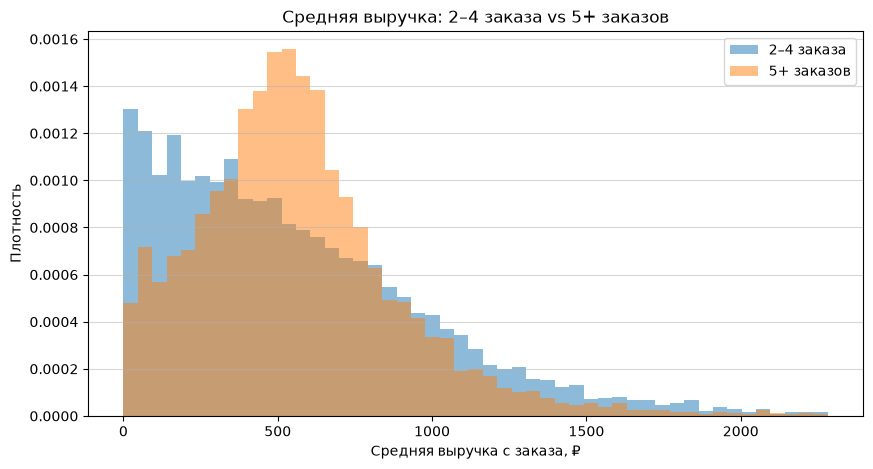

In [58]:
rev_2_4 = user_profile.loc[user_profile['orders_quantity'].between(2, 4), 'avg_revenue_rub']
rev_5p  = user_profile.loc[user_profile['orders_quantity'] >= 5, 'avg_revenue_rub']

upper = user_profile['avg_revenue_rub'].quantile(0.99)
bins = np.linspace(0, upper, 50)

plt.figure(figsize=(10, 5))
plt.hist(rev_2_4[rev_2_4 < upper], bins=bins, density=True, alpha=0.5, label='2–4 заказа')
plt.hist(rev_5p[rev_5p < upper],  bins=bins, density=True, alpha=0.5, label='5+ заказов')
plt.xlabel('Средняя выручка с заказа, ₽')
plt.ylabel('Плотность')
plt.title('Средняя выручка: 2–4 заказа vs 5+ заказов')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

In [59]:
pd.DataFrame({
    '2–4 заказа': rev_2_4.describe(),
    '5+ заказов': rev_5p.describe(),
}).round(2)

,2–4 заказа,5+ заказов
count,7159.00,6400.00
mean,580.64,576.26
std,568.42,431.16
min,0.00,0.00
25%,219.27,345.54
50%,475.60,528.00
75%,811.10,726.87
max,16738.69,16475.35


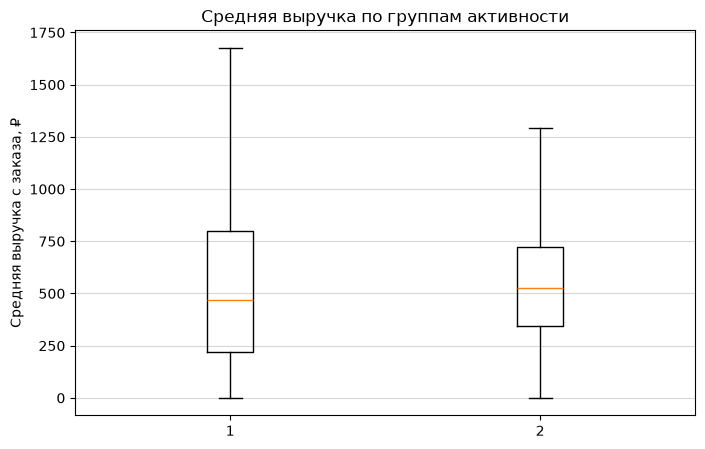

In [60]:
upper = user_profile['avg_revenue_rub'].quantile(0.99)
plt.figure(figsize=(8, 5))
plt.boxplot(
    [rev_2_4[rev_2_4 < upper], rev_5p[rev_5p < upper]],
    label=['2–4 заказа', '5+ заказов'],
    showfliers=False,
)
plt.ylabel('Средняя выручка с заказа, ₽')
plt.title('Средняя выручка по группам активности')
plt.grid(axis='y', alpha=0.5)
plt.show()

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

count    21933.00
mean         2.76
std          0.92
min          1.00
25%          2.00
50%          2.76
75%          3.12
max         12.00
Name: avg_tickets_quantity, dtype: float64


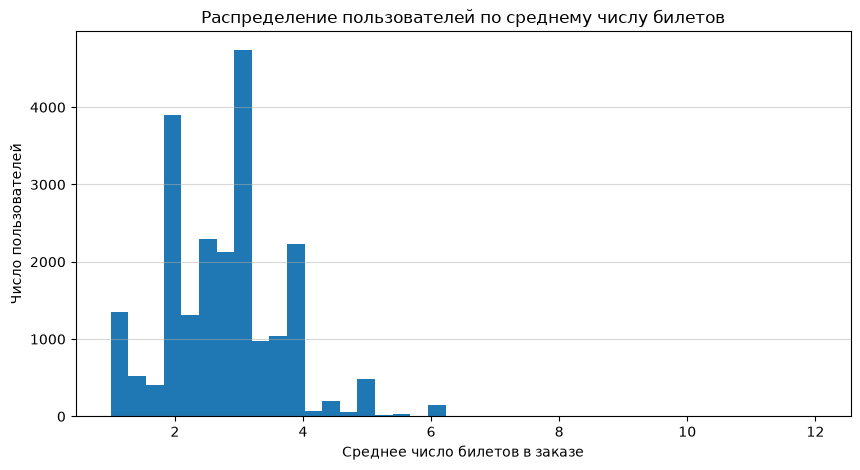

In [61]:
print(user_profile['avg_tickets_quantity'].describe().round(2))

plt.figure(figsize=(10, 5))
user_profile['avg_tickets_quantity'].plot(kind='hist', bins=40)
plt.xlabel('Среднее число билетов в заказе')
plt.ylabel('Число пользователей')
plt.title('Распределение пользователей по среднему числу билетов')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [62]:
bins = [1, 2, 3, 5, np.inf]
labels = ['1–2', '2–3', '3–5', '5+']
user_profile['tickets_segment'] = pd.cut(
    user_profile['avg_tickets_quantity'], bins=bins, labels=labels, right=False
)

seg_tickets = pd.DataFrame({
    'users_count': user_profile['tickets_segment'].value_counts().sort_index(),
    'repeat_share': user_profile.groupby('tickets_segment', observed=True)['is_two'].mean().round(3),
})
seg_tickets

,users_count,repeat_share
tickets_segment,,
1–2,2401,0.512
2–3,9642,0.741
3–5,9201,0.549
5+,689,0.193


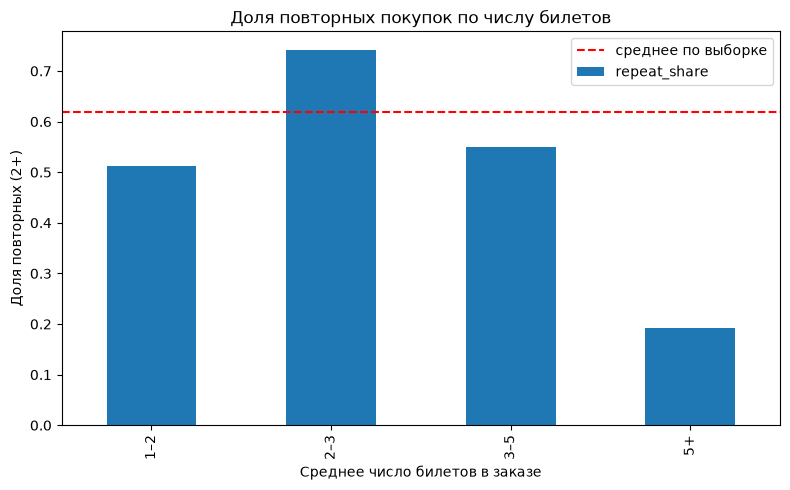

In [63]:
ax = seg_tickets['repeat_share'].plot(kind='bar', figsize=(8, 5), title='Доля повторных покупок по числу билетов')
ax.axhline(user_profile['is_two'].mean(), color='red', linestyle='--', label='среднее по выборке')
ax.set_xlabel('Среднее число билетов в заказе')
ax.set_ylabel('Доля повторных (2+)')
ax.legend()
plt.tight_layout()
plt.show()

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


In [64]:
user_profile['first_order_date'] = pd.to_datetime(user_profile['first_order_date'])
user_profile['first_order_weekday'] = user_profile['first_order_date'].dt.dayofweek
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

In [65]:
seg_weekday = pd.DataFrame({
    'users_count': user_profile['first_order_weekday'].value_counts().sort_index(),
    'repeat_share': user_profile.groupby('first_order_weekday')['is_two'].mean().round(3),
})
seg_weekday.index = weekday_names
seg_weekday

,users_count,repeat_share
Пн,2947,0.634
Вт,3218,0.625
Ср,3084,0.625
Чт,3130,0.596
Пт,3274,0.599
Сб,3461,0.641
Вс,2819,0.606


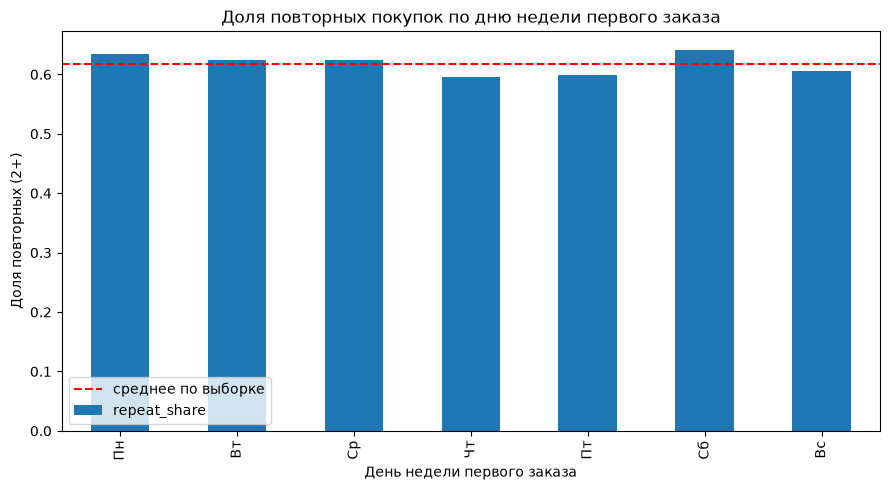

In [66]:
ax = seg_weekday['repeat_share'].plot(kind='bar', figsize=(9, 5), title='Доля повторных покупок по дню недели первого заказа')
ax.axhline(user_profile['is_two'].mean(), color='red', linestyle='--', label='среднее по выборке')
ax.set_xlabel('День недели первого заказа')
ax.set_ylabel('Доля повторных (2+)')
ax.legend()
plt.tight_layout()
plt.show()

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [67]:
interval_2_4 = user_profile.loc[user_profile['orders_quantity'].between(2, 4), 'avg_days_since_prev']
interval_5p  = user_profile.loc[user_profile['orders_quantity'] >= 5, 'avg_days_since_prev']

pd.DataFrame({
    '2–4 заказа': interval_2_4.describe(),
    '5+ заказов': interval_5p.describe(),
}).round(2)

,2–4 заказа,5+ заказов
count,7159.00,6400.00
mean,18.64,9.37
std,29.79,8.15
min,-128.00,-32.00
25%,0.00,3.35
50%,8.00,7.75
75%,32.00,13.75
max,127.00,37.50


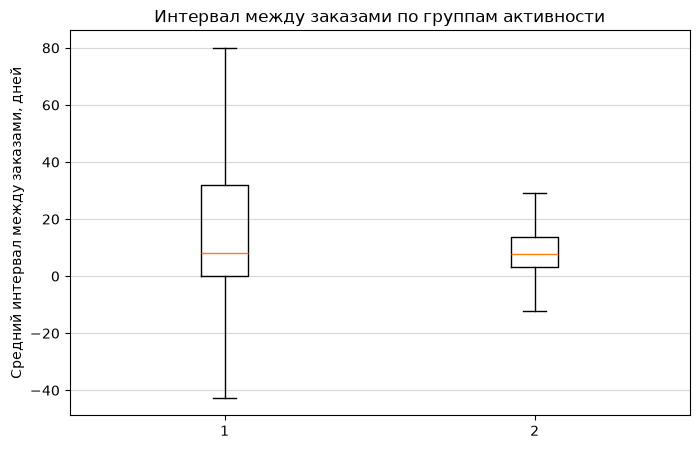

In [69]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [interval_2_4.dropna(), interval_5p.dropna()],
    label=['2–4 заказа', '5+ заказов'],
    showfliers=False,
)
plt.ylabel('Средний интервал между заказами, дней')
plt.title('Интервал между заказами по группам активности')
plt.grid(axis='y', alpha=0.5)
plt.show()

In [70]:
print('Средний интервал, 2–4 заказа: {:.1f} дн.'.format(interval_2_4.mean()))
print('Средний интервал, 5+ заказов: {:.1f} дн.'.format(interval_5p.mean()))

Средний интервал, 2–4 заказа: 18.6 дн.
Средний интервал, 5+ заказов: 9.4 дн.


---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

In [76]:
import phik

corr_cols = [
    'first_event_type', 'first_order_device', 'first_order_region', 'first_service_name',
    'avg_revenue_rub', 'avg_tickets_quantity', 'avg_days_since_prev', 'orders_quantity',
]
interval_cols = ['avg_revenue_rub', 'avg_tickets_quantity', 'avg_days_since_prev', 'orders_quantity']

phik_overall = user_profile[corr_cols].phik_matrix(interval_cols=interval_cols)
phik_overall['orders_quantity'].sort_values(ascending=False)

orders_quantity         1.000000
first_order_region      0.127480
first_service_name      0.103566
first_order_device      0.000000
first_event_type        0.000000
avg_revenue_rub         0.000000
avg_tickets_quantity    0.000000
avg_days_since_prev     0.000000
Name: orders_quantity, dtype: float64

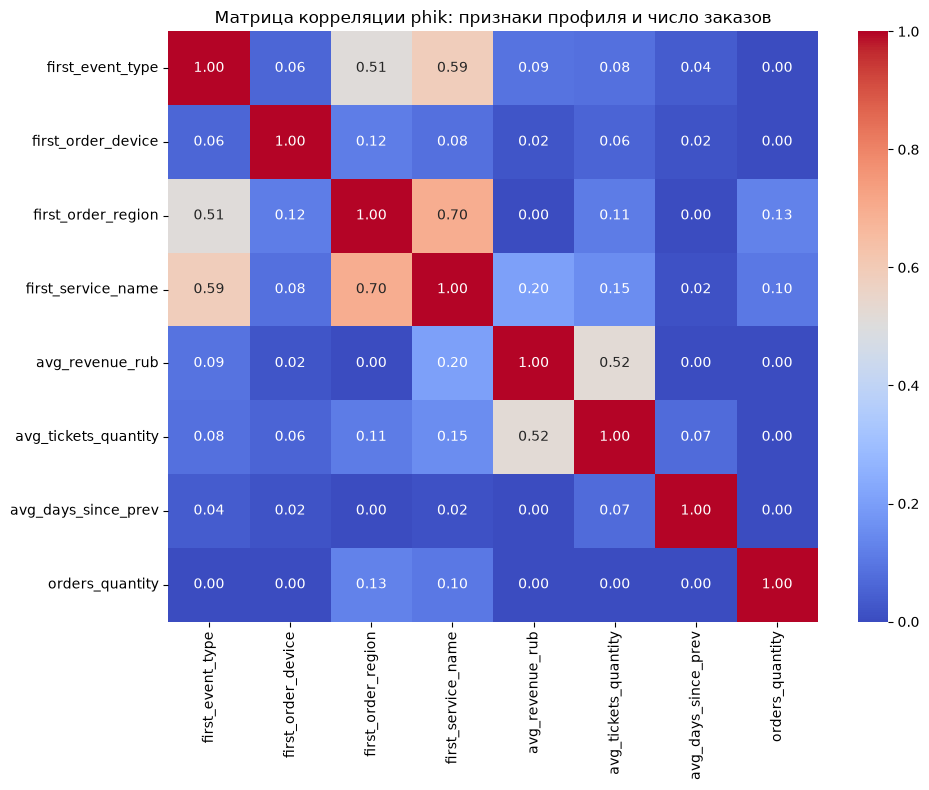

In [77]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(phik_overall, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Матрица корреляции phik: признаки профиля и число заказов')
plt.tight_layout()
plt.show()

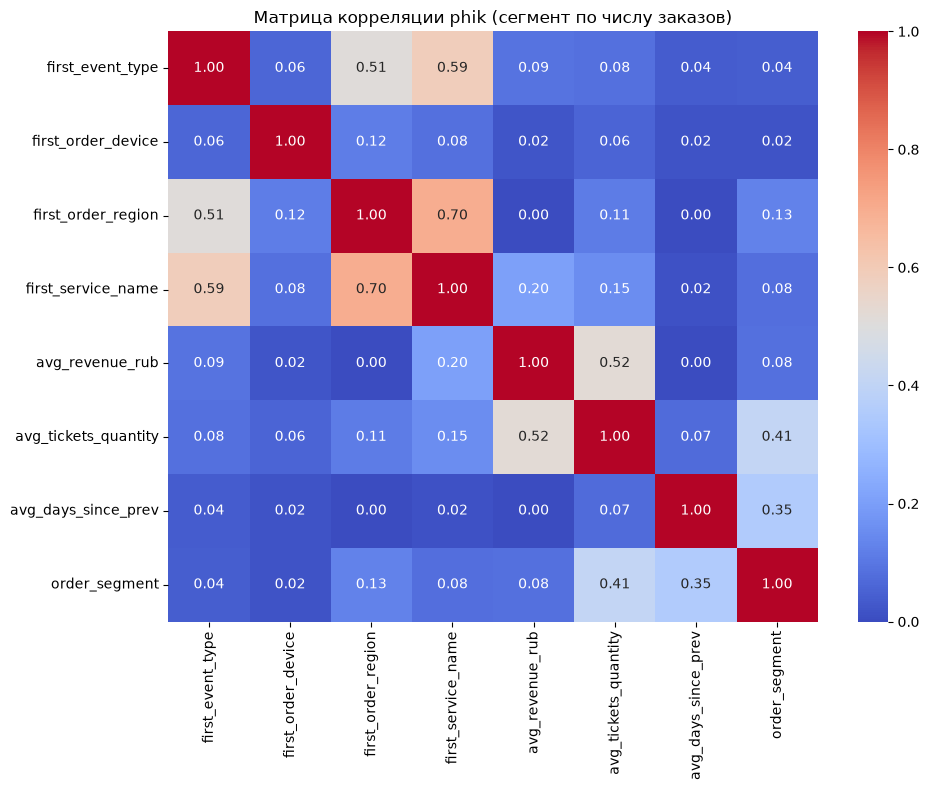

order_segment           1.000000
avg_tickets_quantity    0.409590
avg_days_since_prev     0.354559
first_order_region      0.125771
avg_revenue_rub         0.082467
first_service_name      0.081366
first_event_type        0.041346
first_order_device      0.016681
Name: order_segment, dtype: float64

In [78]:
def order_segment(n):
    if n == 1:
        return '1 заказ'
    elif n <= 4:
        return '2–4 заказа'
    return '5+ заказов'

user_profile['order_segment'] = user_profile['orders_quantity'].apply(order_segment)

corr_cols_seg = [
    'first_event_type', 'first_order_device', 'first_order_region', 'first_service_name',
    'avg_revenue_rub', 'avg_tickets_quantity', 'avg_days_since_prev', 'order_segment',
]
interval_cols_seg = ['avg_revenue_rub', 'avg_tickets_quantity', 'avg_days_since_prev']

phik_seg = user_profile[corr_cols_seg].phik_matrix(interval_cols=interval_cols_seg)

plt.figure(figsize=(10, 8))
sns.heatmap(phik_seg, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1)
plt.title('Матрица корреляции phik (сегмент по числу заказов)')
plt.tight_layout()
plt.show()

phik_seg['order_segment'].sort_values(ascending=False)

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

### 6. Финализация проекта и публикация в Git

Когда вы закончите анализировать данные, оформите проект, а затем опубликуйте его.

Выполните следующие действия:

1. Создайте файл `.gitignore`. Добавьте в него все временные и чувствительные файлы, которые не должны попасть в репозиторий.
2. Сформируйте файл `requirements.txt`. Зафиксируйте все библиотеки, которые вы использовали в проекте.
3. Вынести все чувствительные данные (параметры подключения к базе) в `.env`файл.
4. Проверьте, что проект запускается и воспроизводим.
5. Загрузите проект в публичный репозиторий — например, на GitHub. Убедитесь, что все нужные файлы находятся в репозитории, исключая те, что в `.gitignore`. Ссылка на репозиторий понадобится для отправки проекта на проверку. Вставьте её в шаблон проекта в тетрадке Jupyter Notebook перед отправкой проекта на ревью.

**Вставьте ссылку на проект в этой ячейке тетрадки перед отправкой проекта на ревью.**